# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

In [3]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

RandomForestRegressor()

In [4]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

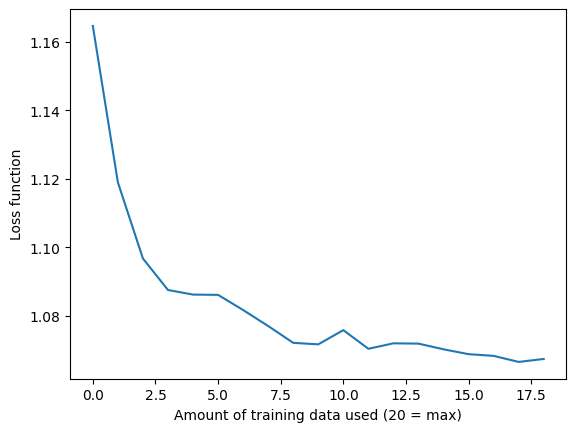

In [5]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [6]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

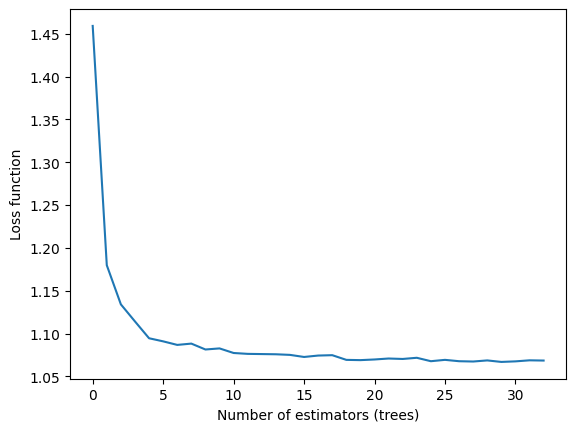

In [7]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

In analyzing the two plots, I would consider cutting the second plot that shows the "Number of estimators (trees)." The reason for this is that the first plot, which shows the "Amount of training data used," provides a more insightful representation of how the model's performance improves with more training data. As we know, machine learning models generally perform better as they are trained on more data, so this plot offers valuable insights into the impact of increasing training data.

On the other hand, the second plot, which shows how the performance changes with the "Number of estimators," is still informative but might be less crucial. In practice, the number of estimators in a Random Forest model might not have as large an effect on model performance after a certain point. Adding more trees typically provides diminishing returns once the model reaches a sufficient number of estimators. Therefore, this plot can be considered less impactful compared to the first.

For plot no 1 The x-axis should indeed represent "Amount of training data used" because we're examining how the model's performance changes as the amount of data increases. For plot no 2 The x-axis here should represent "Number of estimators" because the plot is showing how the performance changes with the number of trees in the Random Forest model. So the current setup is proper.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

In [34]:
# 1st dataset: Austin dataset

import pandas as pd
from sklearn.model_selection import train_test_split

file_path = "/Users/sohanaziz/Documents/AI for leaders sem 2/Datasets/cleaned datasets/week 2/cleaned_austin_data.csv"
df = pd.read_csv(file_path)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15171 entries, 0 to 15170
Data columns (total 44 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   city                            15171 non-null  object 
 1   zipcode                         15171 non-null  int64  
 2   propertyTaxRate                 15171 non-null  float64
 3   garageSpaces                    15171 non-null  int64  
 4   hasAssociation                  15171 non-null  bool   
 5   hasCooling                      15171 non-null  bool   
 6   hasHeating                      15171 non-null  bool   
 7   hasSpa                          15171 non-null  bool   
 8   hasView                         15171 non-null  bool   
 9   parkingSpaces                   15171 non-null  int64  
 10  yearBuilt                       15171 non-null  int64  
 11  latestPrice                     15171 non-null  float64
 12  numPriceChanges                 

In [35]:
# Define features (excluding target 'latestPrice' and ID-like columns)
X = df.drop(columns=['latestPrice', 'city', 'latest_saledate', 'zipcode'])
y = df['latestPrice']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [37]:
# Random Forrest

from sklearn.ensemble import RandomForestRegressor

# Simple and fast model
rf = RandomForestRegressor(
    n_estimators=50,   
    max_depth=10,      
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

In [38]:
# Cross validation

from sklearn.model_selection import cross_val_score

# Quick evaluation: fewer folds
cv_scores = cross_val_score(
    rf, X, y, cv=3, scoring='r2'
)

print(f"Cross-Validation R² Scores: {cv_scores}")
print(f"Mean R²: {cv_scores.mean():.3f}")

Cross-Validation R² Scores: [0.27925374 0.57421626 0.40342412]
Mean R²: 0.419


In [43]:
# Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV

# Small grid for speed
param_grid = {
    'n_estimators': list(range(150, 251, 10)),       
    'max_depth': [5, 10, 15, None],        
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,              
    scoring='r2',
    n_jobs=-1          
)

grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")

Best Parameters: {'max_depth': None, 'n_estimators': 200}


In [42]:
# Evaluate the best model

from sklearn.metrics import mean_squared_error, r2_score

# Predict with best model
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

# Evaluation
r2 = r2_score(y_test, y_pred_best)
rmse = mean_squared_error(y_test, y_pred_best) ** 0.5

print(f"R² Score: {r2:.3f}")
print(f"Root Mean Squared Error: {rmse:.2f}")

R² Score: 0.550
Root Mean Squared Error: 326372.85


In [10]:
# 2nd dataset

import pandas as pd
from sklearn.model_selection import train_test_split

# Load the dataset
file_path = "/Users/sohanaziz/Documents/AI for leaders sem 2/Datasets/cleaned datasets/week 2/cleaned_airbnb_data.csv"
df2 = pd.read_csv(file_path)

df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14448 entries, 0 to 14447
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14448 non-null  int64  
 1   name                            14448 non-null  object 
 2   host_id                         14448 non-null  int64  
 3   host_name                       14448 non-null  object 
 4   neighbourhood                   14448 non-null  object 
 5   latitude                        14448 non-null  float64
 6   longitude                       14448 non-null  float64
 7   room_type                       14448 non-null  object 
 8   price                           14448 non-null  float64
 9   minimum_nights                  14448 non-null  int64  
 10  number_of_reviews               14448 non-null  int64  
 11  last_review                     12243 non-null  object 
 12  reviews_per_month               

In [11]:
# Select numerical features as predictors

X = df2[[
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "number_of_reviews_ltm",
    "room_type_Entire home/apt",
    "room_type_Hotel room",
    "room_type_Private room",
    "room_type_Shared room"
]]

# Target variable
y = df2["price"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
# Random forrest model

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=50,     
    max_depth=10,        
    random_state=42,
    n_jobs=-1            
)

rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=50, n_jobs=-1, random_state=42)

In [13]:
# Cross validation

from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation
cv_scores = cross_val_score(rf, X, y, cv=3, scoring='r2', n_jobs=-1)

print(f"Cross-Validation R² Scores: {cv_scores}")
print(f"Mean R²: {cv_scores.mean():.3f}")

Cross-Validation R² Scores: [-0.97873066 -0.75048022  0.00128835]
Mean R²: -0.576


Fitting 3 folds for each of 80 candidates, totalling 240 fits


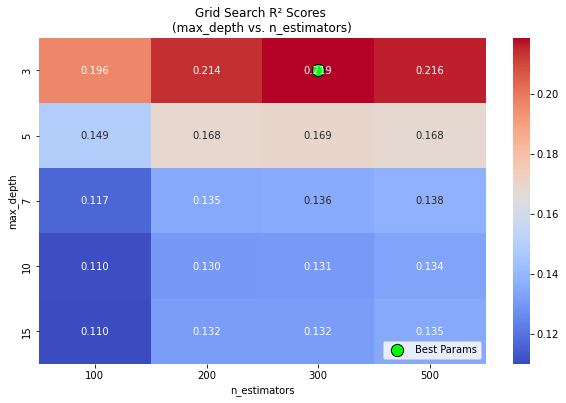

Best Parameters: {'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 300}
Best Cross-Validated R²: 0.219


In [18]:
# Gridsearch 

from sklearn.model_selection import GridSearchCV

# Define hyperparameter grid

param_grid = {
    'n_estimators': [100, 200, 300, 500],          
    'max_depth': [3, 5, 7, 10, 15],               
    'min_samples_split': [2, 5, 10, 20],         
}

# Model & Grid Search
model = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(model, param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

# Extract results
results = pd.DataFrame(grid_search.cv_results_)

# Focus on max_depth and n_estimators for 2D plot
pivot_table = results.pivot_table(
    values='mean_test_score',
    index='param_max_depth',
    columns='param_n_estimators'
)

# Plotting heatmap
plt.figure(figsize=(10,6))
sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="coolwarm")
plt.title("Grid Search R² Scores \n(max_depth vs. n_estimators)")
plt.xlabel("n_estimators")
plt.ylabel("max_depth")

# Annotate Best Parameters
best_params = grid_search.best_params_
best_score = grid_search.best_score_

plt.scatter(
    x=list(param_grid['n_estimators']).index(best_params['n_estimators']) + 0.5,
    y=list(param_grid['max_depth']).index(best_params['max_depth']) + 0.5,
    s=150, c='lime', edgecolors='black', label='Best Params'
)
plt.legend(loc='lower right')
plt.show()

# Print Best Parameters
print(f"Best Parameters: {best_params}")
print(f"Best Cross-Validated R²: {best_score:.3f}")

In [19]:
# Evaluating the best model

from sklearn.metrics import mean_squared_error, r2_score

# Predict using the best model
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

r2 = r2_score(y_test, y_pred_best)
rmse = mean_squared_error(y_test, y_pred_best, squared=False)

print(f"R² Score: {r2:.3f}")
print(f"Root Mean Squared Error: {rmse:.2f}")


R² Score: 0.783
Root Mean Squared Error: 131.89


In [20]:
# 3rd dataset: real estate

import pandas as pd
from sklearn.model_selection import train_test_split

# Load dataset
file_path = "/Users/sohanaziz/Documents/AI for leaders sem 2/Datasets/cleaned datasets/week 2/updated_real_estate.csv"
df3 = pd.read_csv(file_path)

df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2223239 entries, 0 to 2223238
Data columns (total 11 columns):
 #   Column             Dtype  
---  ------             -----  
 0   status             object 
 1   price              float64
 2   bed                float64
 3   bath               float64
 4   acre_lot           float64
 5   city               object 
 6   state              object 
 7   zip_code           float64
 8   house_size         float64
 9   prev_sold_date     object 
 10  prev_sold_encoded  int64  
dtypes: float64(6), int64(1), object(4)
memory usage: 186.6+ MB


In [21]:
# Select numerical features
X = df3[["bed", "bath", "acre_lot", "house_size", "prev_sold_encoded"]]
y = df3["price"]

# Simple train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=50,   
    max_depth=10,     
    random_state=42
)

rf.fit(X_train, y_train)

# Quick prediction
y_pred = rf.predict(X_test)

In [23]:
# cross validation

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf, X, y, cv=3, scoring='r2'
)

print(f"Cross-Validation R² Scores: {cv_scores}")
print(f"Mean R²: {cv_scores.mean():.3f}")

Cross-Validation R² Scores: [0.09188291 0.09737338 0.17861725]
Mean R²: 0.123


In [26]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 150, 200],         
    'max_depth': [5, 10, 20, None],       
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")

/Users/sohanaziz/opt/anaconda3/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:702: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Parameters: {'max_depth': 10, 'n_estimators': 200}


In [27]:
from sklearn.metrics import mean_squared_error, r2_score

# Predict using tuned model
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

# Evaluation
r2 = r2_score(y_test, y_pred_best)
rmse = mean_squared_error(y_test, y_pred_best) ** 0.5

print(f"R² Score: {r2:.3f}")
print(f"Root Mean Squared Error: {rmse:.2f}")

R² Score: 0.128
Root Mean Squared Error: 1727659.63


# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

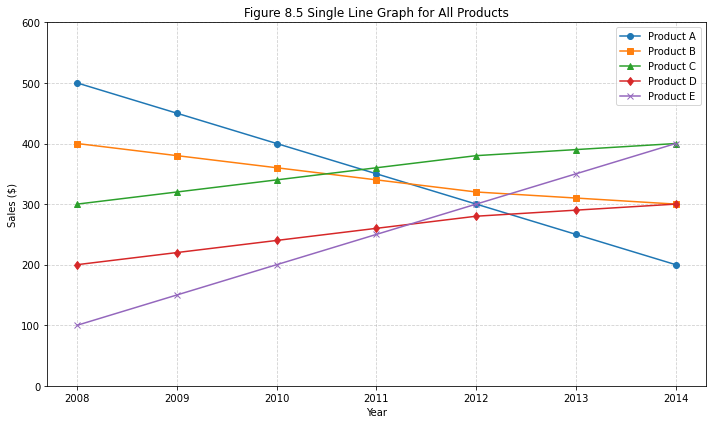

In [44]:
import matplotlib.pyplot as plt

# Sample data for products (replace with your actual values!)
years = [2008, 2009, 2010, 2011, 2012, 2013, 2014]

product_A = [500, 450, 400, 350, 300, 250, 200]
product_B = [400, 380, 360, 340, 320, 310, 300]
product_C = [300, 320, 340, 360, 380, 390, 400]
product_D = [200, 220, 240, 260, 280, 290, 300]
product_E = [100, 150, 200, 250, 300, 350, 400]

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(years, product_A, marker='o', label='Product A')
plt.plot(years, product_B, marker='s', label='Product B')
plt.plot(years, product_C, marker='^', label='Product C')
plt.plot(years, product_D, marker='d', label='Product D')
plt.plot(years, product_E, marker='x', label='Product E')

# Customizing
plt.title('Figure 8.5 Single Line Graph for All Products')
plt.xlabel('Year')
plt.ylabel('Sales ($)')
plt.xticks(years)  # ensures each year is marked
plt.yticks(range(0, 601, 100))  # matches the $0-$500 scale
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Show plot
plt.tight_layout()
plt.show()